# Here is the Step4 about SHD Dataset

In [1]:
import pickle
import random
import numpy as np
from scipy import io
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as tnnf
from tqdm.notebook import tqdm
# from utils import get_shd_dataset

ms = 1e-3 # use this constant so you can write e.g. 1*ms for a time

## Create Inverse SHD Dataset

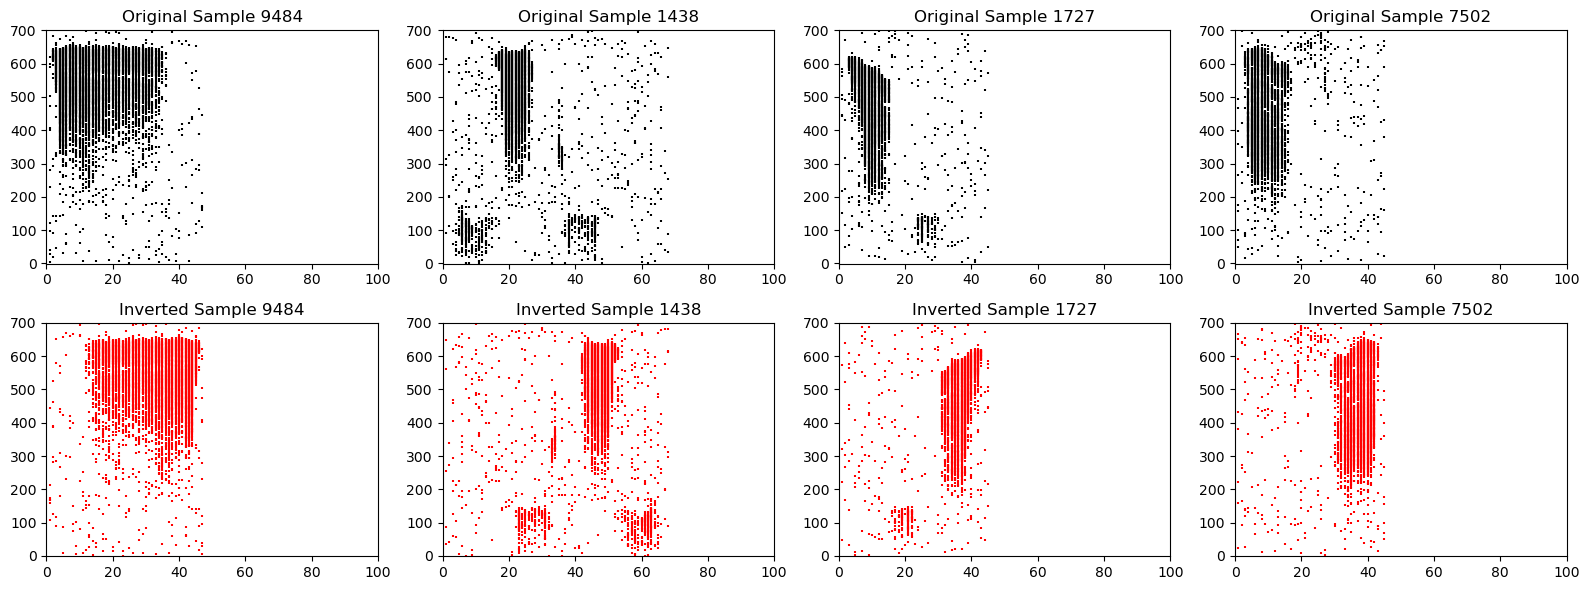

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
import random

data = loadmat("shd_whole.mat")
X = data["X"]  # (N, num_neurons, T)
Y = data["Y"].ravel()
N, num_neurons, T = X.shape

# For each sample, find the start and end time of spikes and flip the segments
X_inv = np.copy(X)
for i in range(N):
    spike_times = np.where(X[i] == 1)[1]
    if len(spike_times) == 0:
        continue
    t_start = np.min(spike_times)
    t_end = np.max(spike_times)
    for j in range(num_neurons):
        segment = X[i, j, t_start:t_end + 1]
        X_inv[i, j, t_start:t_end + 1] = np.flip(segment)

# Visualize original and inverted samples
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
sample_indices = random.sample(range(N), 4)
for i, idx in enumerate(sample_indices):
    ax1 = axes[0, i]
    for neuron in range(num_neurons):
        t_spike = np.where(X[idx, neuron] == 1)[0]
        ax1.scatter(t_spike, np.ones_like(t_spike) * neuron, s=3, marker='|', color='black')
    ax1.set_title(f"Original Sample {idx}")
    ax1.set_ylim([-1, num_neurons])
    ax1.set_xlim([0, T])
    
    ax2 = axes[1, i]
    for neuron in range(num_neurons):
        t_spike = np.where(X_inv[idx, neuron] == 1)[0]
        ax2.scatter(t_spike, np.ones_like(t_spike) * neuron, s=3, marker='|', color='red')
    ax2.set_title(f"Inverted Sample {idx}")
    ax2.set_ylim([-1, num_neurons])
    ax2.set_xlim([0, T])

plt.tight_layout()
plt.show()

savemat("shd_whole_inv.mat", {"X": X_inv, "Y": Y})


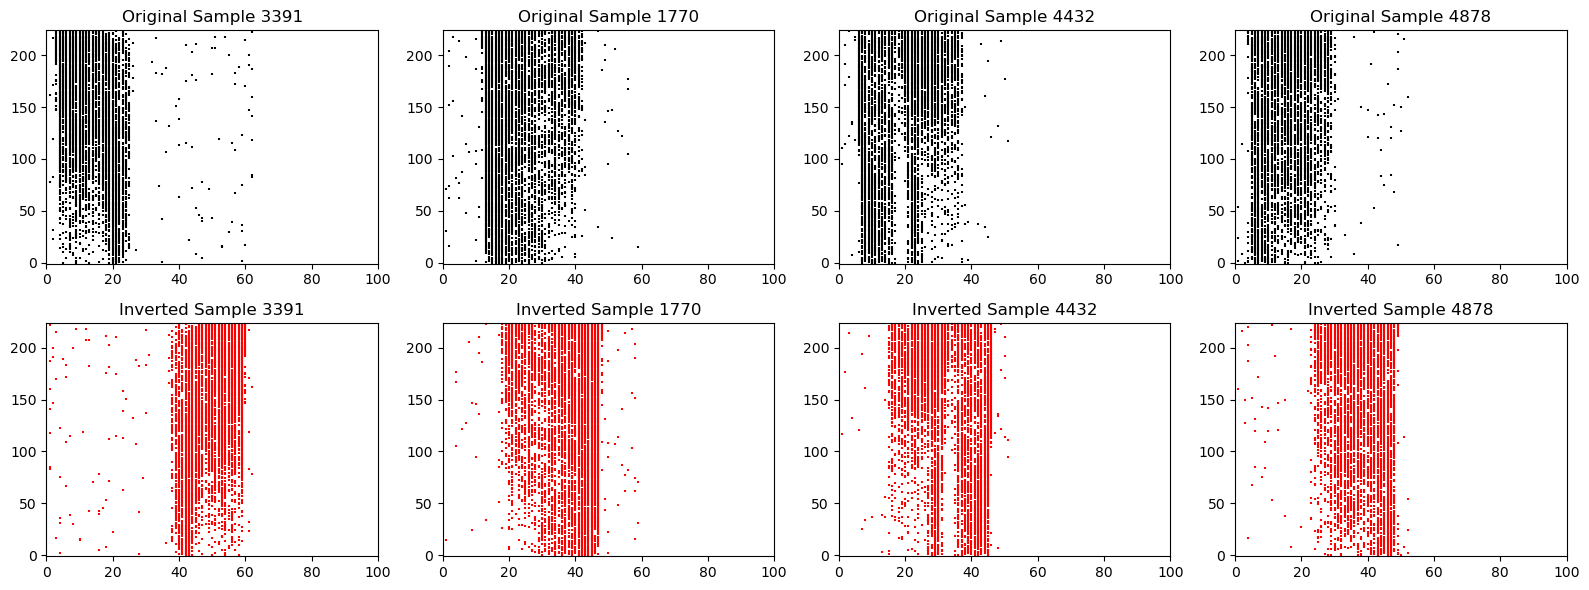

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
import random

data = loadmat("shd_part_clear.mat")
X = data["X"]  # (N, num_neurons, T)
Y = data["Y"].ravel()
N, num_neurons, T = X.shape

# For each sample, find the start and end time of spikes and flip the segments
X_inv = np.copy(X)
for i in range(N):
    spike_times = np.where(X[i] == 1)[1]
    if len(spike_times) == 0:
        continue
    t_start = np.min(spike_times)
    t_end = np.max(spike_times)
    for j in range(num_neurons):
        segment = X[i, j, t_start:t_end + 1]
        X_inv[i, j, t_start:t_end + 1] = np.flip(segment)

# Visualize original and inverted samples
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
sample_indices = random.sample(range(N), 4)
for i, idx in enumerate(sample_indices):
    ax1 = axes[0, i]
    for neuron in range(num_neurons):
        t_spike = np.where(X[idx, neuron] == 1)[0]
        ax1.scatter(t_spike, np.ones_like(t_spike) * neuron, s=3, marker='|', color='black')
    ax1.set_title(f"Original Sample {idx}")
    ax1.set_ylim([-1, num_neurons])
    ax1.set_xlim([0, T])
    
    ax2 = axes[1, i]
    for neuron in range(num_neurons):
        t_spike = np.where(X_inv[idx, neuron] == 1)[0]
        ax2.scatter(t_spike, np.ones_like(t_spike) * neuron, s=3, marker='|', color='red')
    ax2.set_title(f"Inverted Sample {idx}")
    ax2.set_ylim([-1, num_neurons])
    ax2.set_xlim([0, T])

plt.tight_layout()
plt.show()

savemat("shd_part_inv.mat", {"X": X_inv, "Y": Y})


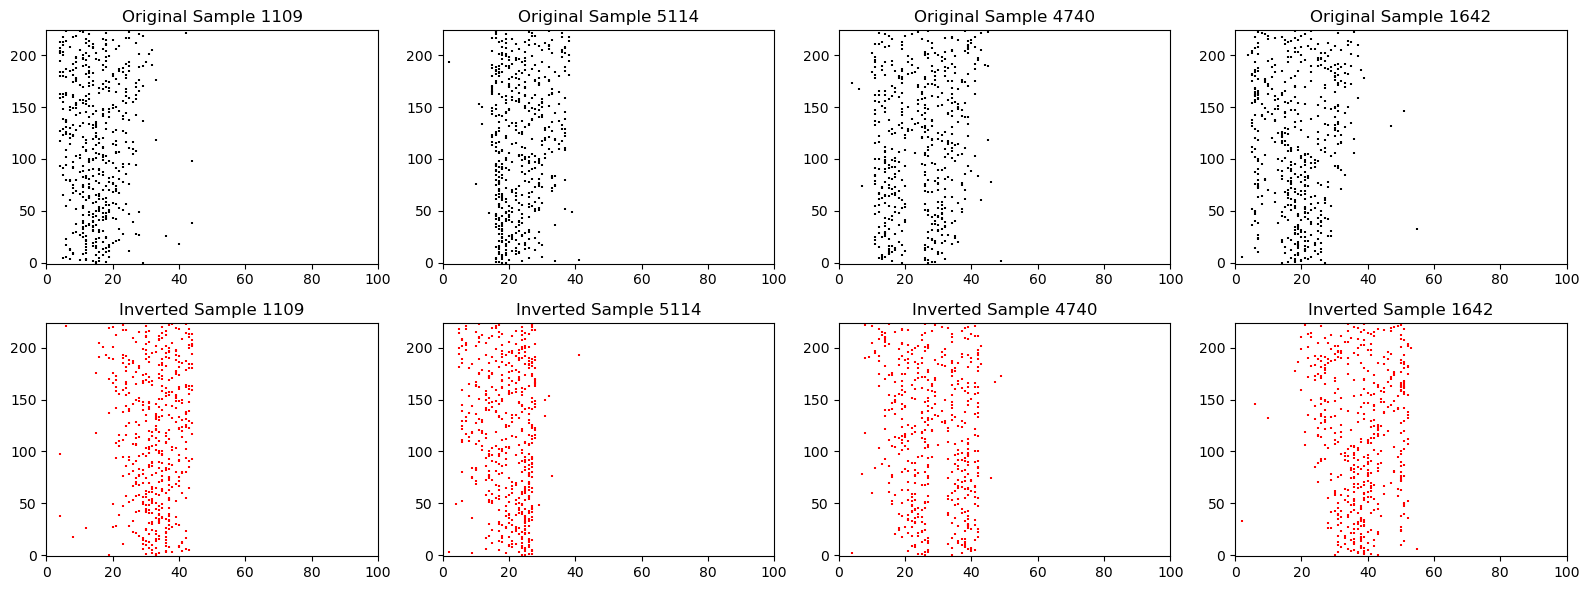

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
import random

data = loadmat("shd_norm_new.mat")
X = data["X"]  # (N, num_neurons, T)
Y = data["Y"].ravel()
N, num_neurons, T = X.shape

# For each sample, find the start and end time of spikes and flip the segments
X_inv = np.copy(X)
for i in range(N):
    spike_times = np.where(X[i] == 1)[1]
    if len(spike_times) == 0:
        continue
    t_start = np.min(spike_times)
    t_end = np.max(spike_times)
    for j in range(num_neurons):
        segment = X[i, j, t_start:t_end + 1]
        X_inv[i, j, t_start:t_end + 1] = np.flip(segment)

# Visualize original and inverted samples
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
sample_indices = random.sample(range(N), 4)
for i, idx in enumerate(sample_indices):
    ax1 = axes[0, i]
    for neuron in range(num_neurons):
        t_spike = np.where(X[idx, neuron] == 1)[0]
        ax1.scatter(t_spike, np.ones_like(t_spike) * neuron, s=3, marker='|', color='black')
    ax1.set_title(f"Original Sample {idx}")
    ax1.set_ylim([-1, num_neurons])
    ax1.set_xlim([0, T])
    
    ax2 = axes[1, i]
    for neuron in range(num_neurons):
        t_spike = np.where(X_inv[idx, neuron] == 1)[0]
        ax2.scatter(t_spike, np.ones_like(t_spike) * neuron, s=3, marker='|', color='red')
    ax2.set_title(f"Inverted Sample {idx}")
    ax2.set_ylim([-1, num_neurons])
    ax2.set_xlim([0, T])

plt.tight_layout()
plt.show()

savemat("shd_norm_inv.mat", {"X": X_inv, "Y": Y})


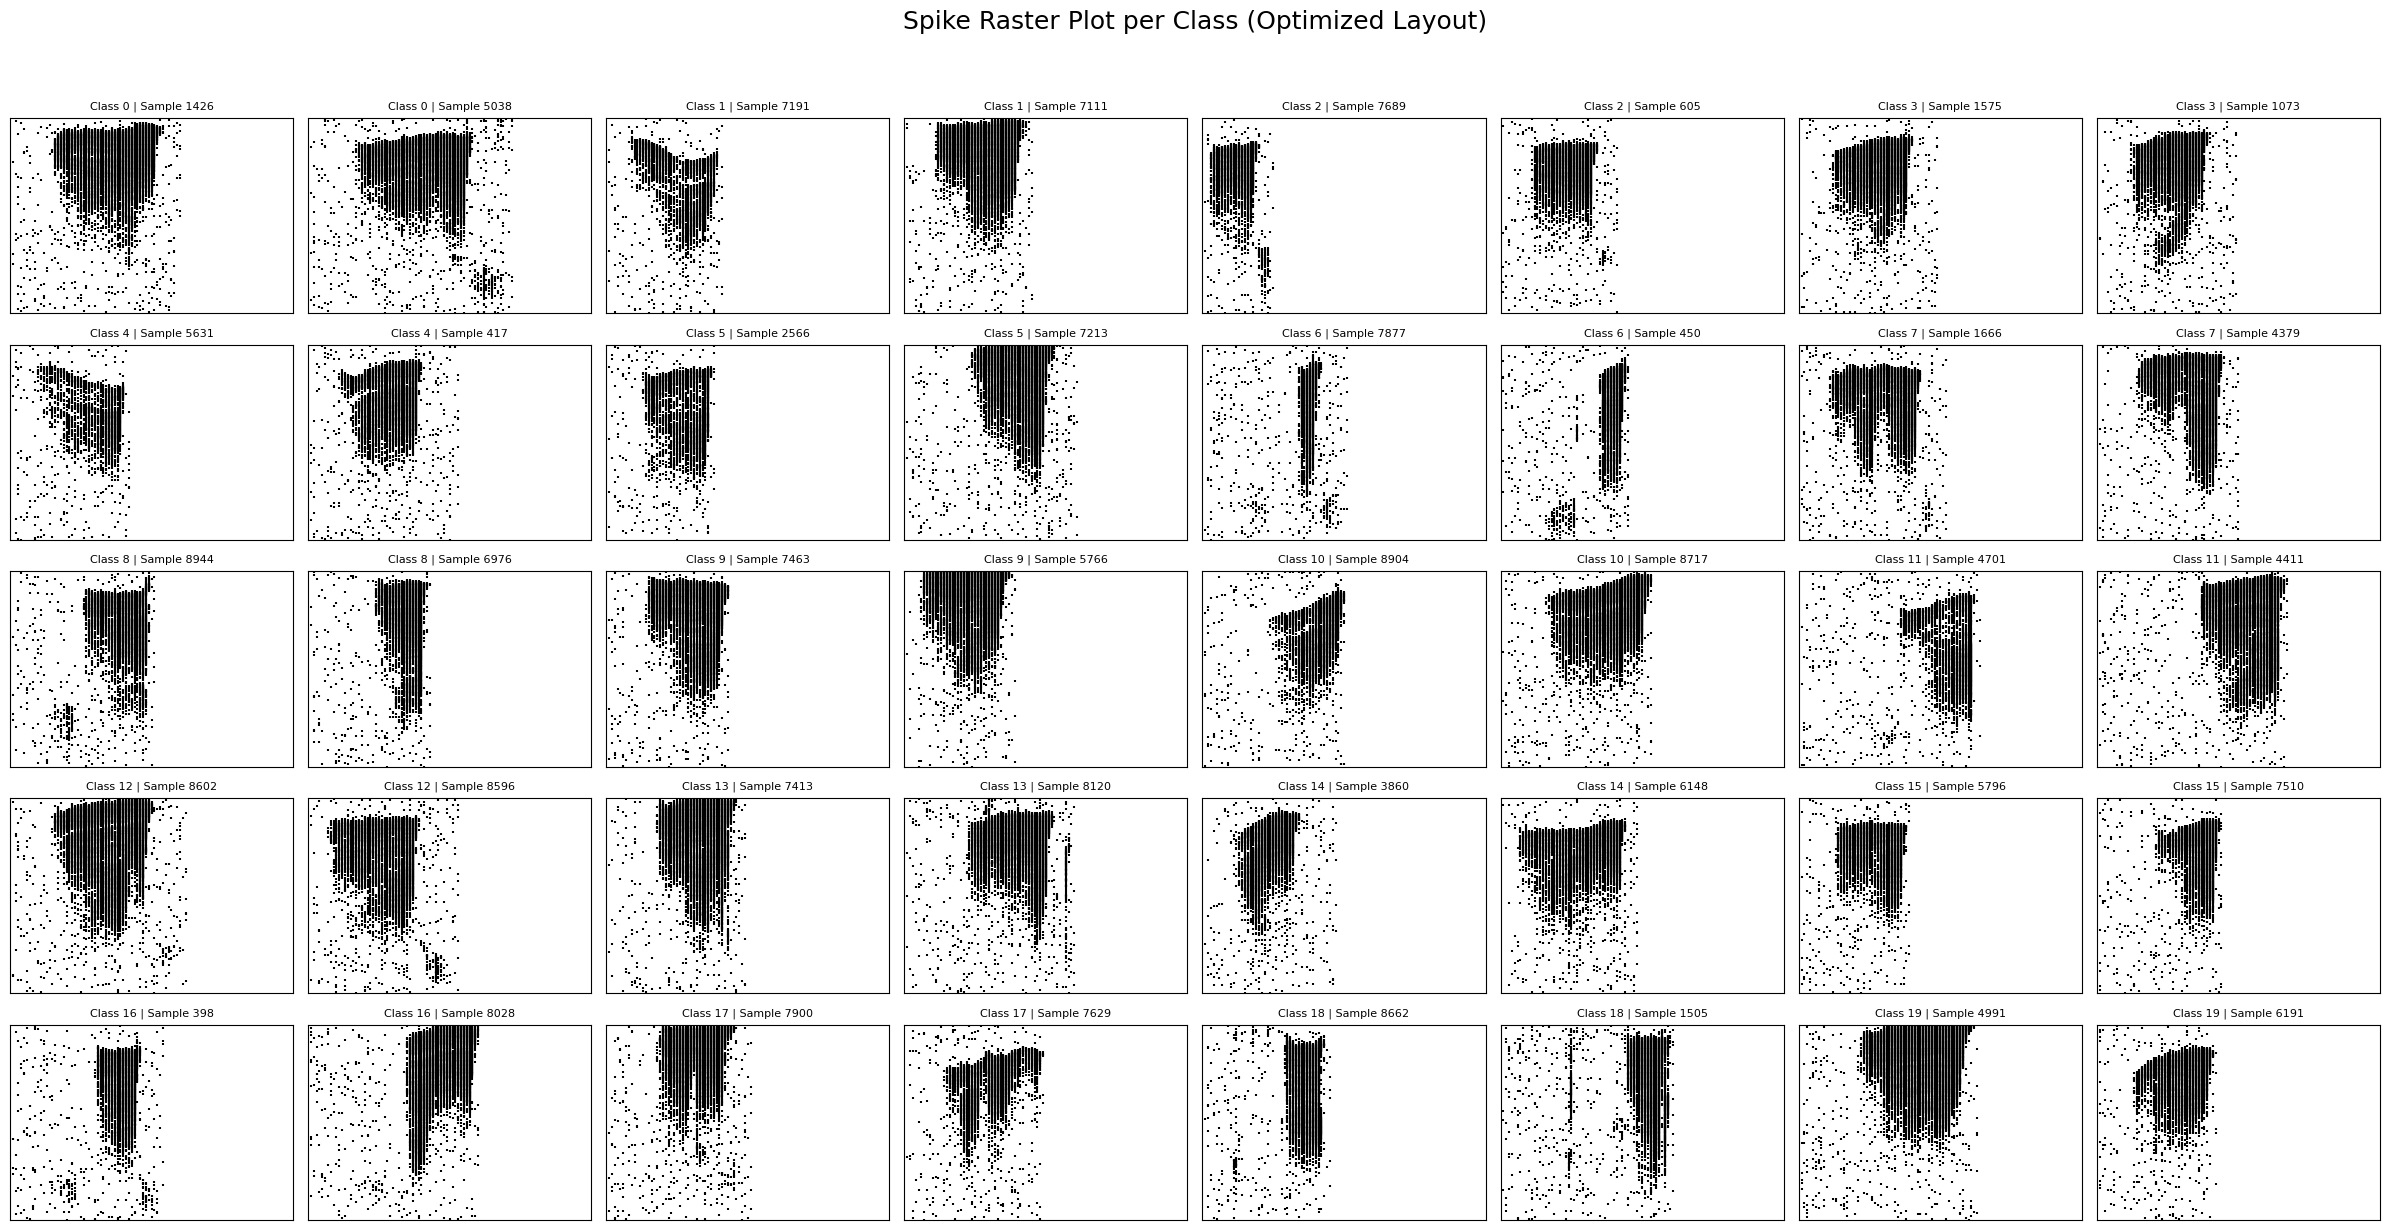

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import io
import math

data = io.loadmat('shd_whole_inv.mat')
X = data['X']  # shape = (N, num_neurons, T)
Y = data['Y'].ravel()

N, num_neurons, T = X.shape
unique_labels = np.unique(Y)
num_classes = len(unique_labels)

num_samples_per_class = 2
total_plots = num_classes * num_samples_per_class

ncols = 8
nrows = math.ceil(total_plots / ncols)

np.random.seed(42)
selected_samples = []
for cls in unique_labels:
    cls_indices = np.where(Y == cls)[0]
    selected = np.random.choice(cls_indices, size=num_samples_per_class, replace=False)
    selected_samples.extend([(int(cls), idx) for idx in selected])

# Visualization
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 2.5*nrows), sharex=True, sharey=True)
axes = axes.flatten()
fig.suptitle("Spike Raster Plot per Class (Optimized Layout)", fontsize=18)

for i, (cls, sample_idx) in enumerate(selected_samples):
    ax = axes[i]
    spike_mat = X[sample_idx, :, :]
    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_mat[neuron_idx] == 1)[0]
        ax.scatter(spike_times, np.ones_like(spike_times)*neuron_idx,
                   s=1.5, marker='|', color='black')

    ax.set_title(f"Class {cls} | Sample {sample_idx}", fontsize=8)
    ax.set_xlim([0, T])
    ax.set_ylim([0, num_neurons])
    ax.set_xticks([])
    ax.set_yticks([])

for j in range(len(selected_samples), len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Begin Here to Train


=== Single Sample (Label=11) ===
Original spike count: 3179
D=0 | Decreased spike count: 3179 | Δ per neuron per sample: 0.00
D=0.5 | Decreased spike count: 3179 | Δ per neuron per sample: 0.00


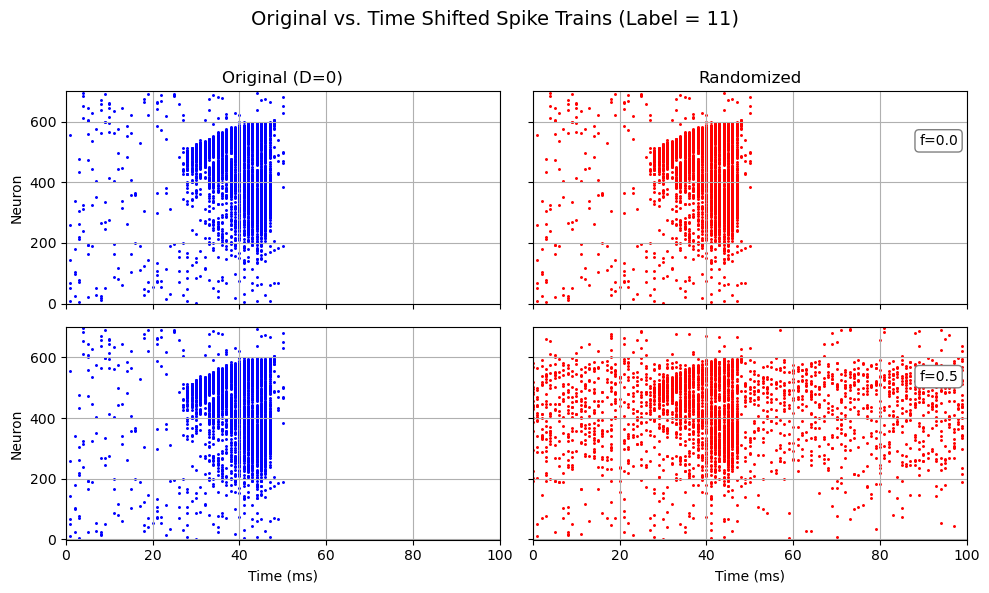


=== Batch Visualization (f=5) ===
Got a batch: x_batch.shape=torch.Size([2, 700, 100]), y_batch=tensor([17, 19])
Sample 0 | Label=17 | Original count=4559 | Shifted count=4559 | Δ per neuron per sample: 0.00
Sample 1 | Label=19 | Original count=5686 | Shifted count=5686 | Δ per neuron per sample: 0.00

=== Batch Overall Δ per neuron per sample: 0.00 ===



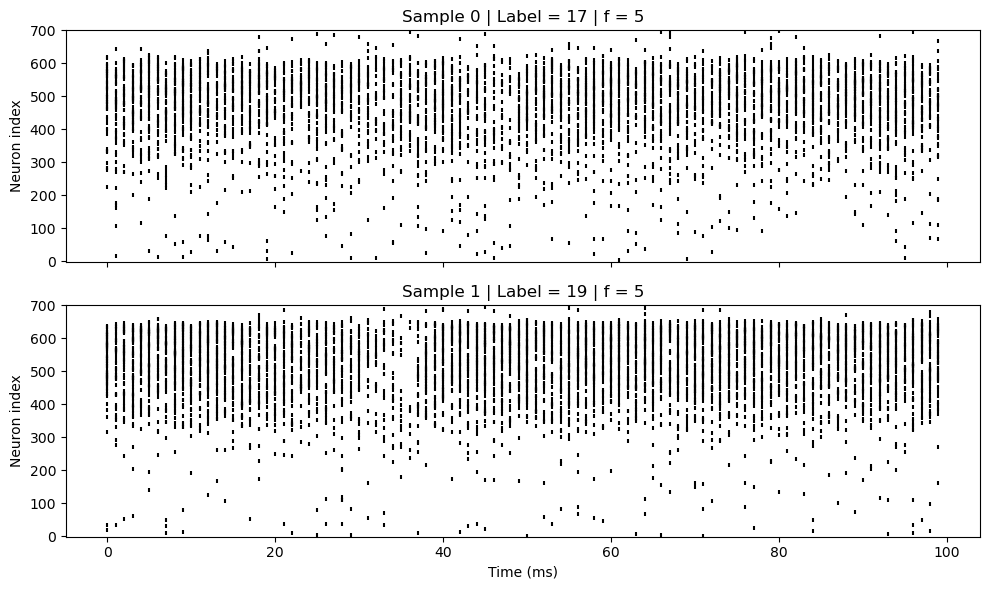

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from torch.utils.data import Dataset, DataLoader


def partial_randomize_spike_train(spike_train, f=0.5, max_attempts=500):
    if f <= 0:
        return spike_train
    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)
    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        for old_time in spike_times:
            if np.random.rand() < f:
                new_train[neuron_idx, old_time] = 0
                inserted = False
                attempts = 0
                while not inserted and attempts < max_attempts:
                    attempts += 1
                    new_t = np.random.randint(0, T)
                    if new_train[neuron_idx, new_t] == 0:
                        new_train[neuron_idx, new_t] = 1
                        inserted = True
    return new_train

class SHDSpikeDataset(Dataset):
    def __init__(self, mat_path):
        data = loadmat(mat_path)
        X = data["X"]
        Y = data["Y"].ravel()
        self.original_shape = X.shape
        self.Y = torch.tensor(Y, dtype=torch.long)
        self.X = torch.tensor(X, dtype=torch.uint8)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

def show_single_sample_different_f(spike_tensor, label, f_values=[0, 0.5]):
    spike_train = spike_tensor.numpy()
    original_spike_count = spike_train.sum()
    print(f"\n=== Single Sample (Label={label}) ===")
    print(f"Original spike count: {int(original_spike_count)}")

    fig, axes = plt.subplots(len(f_values), 2, figsize=(10, 3 * len(f_values)), sharex=True, sharey=True)
    fig.suptitle(f"Original vs. Time Shifted Spike Trains (Label = {label})", fontsize=14)

    for row_i, f_ in enumerate(f_values):
        ax_left = axes[row_i, 0]
        for neuron_idx in range(spike_train.shape[0]):
            spike_times = np.where(spike_train[neuron_idx] == 1)[0]
            ax_left.scatter(spike_times, np.ones_like(spike_times)*neuron_idx, s=5, color='b', marker='.')
        if row_i == 0:
            ax_left.set_title("Original (D=0)")
        ax_left.set_ylabel('Neuron')
        ax_left.grid(True)

        ax_right = axes[row_i, 1]
        randomized = partial_randomize_spike_train(spike_train, f_)
        shifted_spike_count = randomized.sum()
        delta_total = original_spike_count - shifted_spike_count 
        delta_avg_per_neuron = delta_total / spike_train.shape[0]  # per neuron per sample

        print(f"D={f_} | Decreased spike count: {int(shifted_spike_count)} "
              f"| Δ per neuron per sample: {delta_avg_per_neuron:.2f}")

        for neuron_idx in range(randomized.shape[0]):
            spike_times = np.where(randomized[neuron_idx] == 1)[0]
            ax_right.scatter(spike_times, np.ones_like(spike_times)*neuron_idx, s=5, color='r', marker='.')
        if row_i == 0:
            ax_right.set_title("Randomized")
        ax_right.text(0.98, 0.8, f"f={f_:.1f}", transform=ax_right.transAxes,
                      ha='right', va='top', fontsize=10,
                      bbox=dict(boxstyle="round", fc="white", ec="gray"))
        ax_right.grid(True)

        for ax in (ax_left, ax_right):
            ax.set_ylim([-1, spike_train.shape[0]])
            ax.set_xlim([0, spike_train.shape[1]])

    axes[-1, 0].set_xlabel('Time (ms)')
    axes[-1, 1].set_xlabel('Time (ms)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def demo_batch_visualization(loader, f=5):
    x_batch, y_batch = next(iter(loader))
    batch_size = len(y_batch)
    print(f"\n=== Batch Visualization (f={f}) ===")
    print(f"Got a batch: x_batch.shape={x_batch.shape}, y_batch={y_batch}")

    # For batch overall statistics:
    batch_original_spike_count = x_batch.numpy().sum()
    batch_shifted_spike_count = 0

    fig, axes = plt.subplots(batch_size, 1, figsize=(10, 3 * batch_size), sharex=True, sharey=True)
    if batch_size == 1:
        axes = [axes]

    for i in range(batch_size):
        spike_mat = x_batch[i].numpy()
        original_spike_count = spike_mat.sum()

        spike_mat_shifted = partial_randomize_spike_train(spike_mat, f)
        shifted_spike_count = spike_mat_shifted.sum()
        batch_shifted_spike_count += shifted_spike_count

        delta_total = original_spike_count - shifted_spike_count
        delta_avg_per_neuron = delta_total / spike_mat.shape[0] / batch_size  # per neuron per sample

        print(f"Sample {i} | Label={y_batch[i].item()} | Original count={int(original_spike_count)} | "
              f"Shifted count={int(shifted_spike_count)} "
              f"| Δ per neuron per sample: {delta_avg_per_neuron:.2f}")

        ax = axes[i]
        for neuron_idx in range(spike_mat_shifted.shape[0]):
            spike_times = np.where(spike_mat_shifted[neuron_idx] == 1)[0]
            ax.scatter(spike_times, np.ones_like(spike_times) * neuron_idx,
                       s=5, marker='|', color='black')
        ax.set_title(f"Sample {i} | Label = {y_batch[i].item()} | f = {f}")
        ax.set_ylabel("Neuron index")
        ax.set_ylim([-1, spike_mat_shifted.shape[0]])

    # Print batch overall stats:
    delta_total_batch = batch_shifted_spike_count - batch_original_spike_count
    delta_avg_per_neuron_batch = delta_total_batch / (x_batch.shape[1] * batch_size)
    print(f"\n=== Batch Overall Δ per neuron per sample: {delta_avg_per_neuron_batch:.2f} ===\n")

    axes[-1].set_xlabel("Time (ms)")
    plt.tight_layout()
    plt.show()

# === Load dataset and visualize ===
dataset = SHDSpikeDataset("shd_whole_inv.mat")
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# Visualize one sample
show_single_sample_different_f(dataset[0][0], dataset[0][1], f_values=[0, 0.5])

# Visualize one batch
demo_batch_visualization(loader, f=5)

## Build the Spiking Neural Network Model (SNN)

In [2]:
import torch
import torch.nn as nn
import numpy as np


class SurrGradSpike(torch.autograd.Function):
    scale = 100.0 

    @staticmethod
    def forward(ctx, input):
        """
        在 forward 中做 Heaviside(step) 函数
        """
        ctx.save_for_backward(input)
        out = torch.zeros_like(input)
        out[input > 0] = 1.0
        return out

    @staticmethod
    def backward(ctx, grad_output):
        """
        surrogate gradient: d/dx of H(x) ≈ 1/(scale*|x|+1)^2
        """
        (inp,) = ctx.saved_tensors
        grad_input = grad_output.clone()
        grad = grad_input / (SurrGradSpike.scale*torch.abs(inp) + 1.0)**2
        return grad

spike_fn = SurrGradSpike.apply

class TutorialSNN(nn.Module):
    def __init__(self, nb_inputs=224, nb_hidden=200, nb_outputs=20, time_step=1e-3,
                 tau_mem=10e-3, tau_syn=5e-3, weight_scale=0.2, device='cpu'):
        super().__init__()

        self.nb_inputs = nb_inputs
        self.nb_hidden = nb_hidden
        self.nb_outputs = nb_outputs
        self.time_step = time_step
        self.tau_mem = tau_mem
        self.tau_syn = tau_syn
        self.device_str = device

        self.w1 = nn.Parameter(torch.empty((nb_inputs, nb_hidden), dtype=torch.float))
        self.w2 = nn.Parameter(torch.empty((nb_hidden, nb_outputs), dtype=torch.float))

        torch.nn.init.normal_(self.w1, mean=0.0, std=weight_scale / np.sqrt(nb_inputs))
        torch.nn.init.normal_(self.w2, mean=0.0, std=weight_scale / np.sqrt(nb_hidden))

        self.alpha = float(np.exp(-time_step / tau_syn))
        self.beta = float(np.exp(-time_step / tau_mem))

    def forward(self, inputs, dtype=torch.float32):
        if inputs.dim() == 3:
            inputs = inputs.permute(0, 2, 1)  # (B, T, input_size)

        device = torch.device(self.device_str if torch.cuda.is_available() else 'cpu')
        inputs = inputs.to(device=device, dtype=dtype)
        batch_size, nb_steps, _ = inputs.shape

        syn = torch.zeros((batch_size, self.nb_hidden), device=device, dtype=dtype)
        mem = torch.zeros((batch_size, self.nb_hidden), device=device, dtype=dtype)

        mem_rec = []
        spk_rec = []

        h1_from_input = torch.einsum("abc,cd->abd", (inputs, self.w1.to(device)))

        for t in range(nb_steps):
            h1 = h1_from_input[:, t, :]  # no recurrent input
            mthr = mem - 1.0
            out_new = spike_fn(mthr)
            rst = out_new.detach()

            new_syn = self.alpha * syn + h1
            new_mem = (self.beta * mem + syn) * (1.0 - rst)

            mem_rec.append(mem)
            spk_rec.append(out_new)

            mem = new_mem
            syn = new_syn

        mem_rec = torch.stack(mem_rec, dim=1)
        spk_rec = torch.stack(spk_rec, dim=1)

        # Readout
        h2 = torch.einsum("abc,cd->abd", (spk_rec, self.w2.to(device)))
        flt = torch.zeros((batch_size, self.nb_outputs), device=device, dtype=dtype)
        out_read = torch.zeros((batch_size, self.nb_outputs), device=device, dtype=dtype)
        out_rec = [out_read]

        for t in range(nb_steps):
            new_flt = self.alpha * flt + h2[:, t, :]
            new_out = self.beta * out_read + flt
            flt = new_flt
            out_read = new_out
            out_rec.append(out_read)

        out_rec = torch.stack(out_rec, dim=1)
        return out_rec, [mem_rec, spk_rec]


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from scipy.io import loadmat

data = loadmat("shd_whole_inv.mat")
X = data["X"]  # shape: (samples, neurons, 100)
Y = data["Y"].ravel()
num_neurons, T = X.shape[1], X.shape[2]
num_classes = len(np.unique(Y))

training_range   = (0.0, 0.6)
validation_range = (0.6, 0.75)
testing_range    = (0.75, 0.9)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Dataset wrapper ===
class SpikeTensorDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

# === Partial randomization, batch version ===
def partial_randomize_spike_train(spike_train_batch, f=0.0, max_attempts=50):
    """
    Now supports batch of spike trains: (batch, neurons, T)
    """
    if f <= 0:
        return spike_train_batch

    batch_size, num_neurons, T = spike_train_batch.shape
    new_train_batch = np.copy(spike_train_batch)

    for i in range(batch_size):
        for neuron_idx in range(num_neurons):
            spike_times = np.where(spike_train_batch[i, neuron_idx] == 1)[0]
            for old_time in spike_times:
                if np.random.rand() < f:
                    new_train_batch[i, neuron_idx, old_time] = 0
                    inserted = False
                    attempts = 0
                    while not inserted and attempts < max_attempts:
                        attempts += 1
                        new_t = np.random.randint(0, T)
                        if new_train_batch[i, neuron_idx, new_t] == 0:
                            new_train_batch[i, neuron_idx, new_t] = 1
                            inserted = True
    return new_train_batch


# === DataLoader preprocessing ===
def preprocess_full_dataset_dataloader(X, Y, f, batch_size=128, seed=42):
    np.random.seed(seed)
    N = len(Y)
    train_start, train_end = training_range
    val_start, val_end = validation_range
    test_start, test_end = testing_range

    train_indices = np.arange(int(N * train_start), int(N * train_end))
    val_indices   = np.arange(int(N * val_start), int(N * val_end))
    test_indices  = np.arange(int(N * test_start), int(N * test_end))

    np.random.shuffle(train_indices)

    print(f"Applying spike_time_shift with f={f} to train/val/test set...")

    X_train_proc = partial_randomize_spike_train(X[train_indices], f=f)
    X_val_proc   = partial_randomize_spike_train(X[val_indices], f=f)
    X_test_proc  = partial_randomize_spike_train(X[test_indices], f=f)

    Y_train = Y[train_indices]
    Y_val   = Y[val_indices]
    Y_test  = Y[test_indices]

    train_ds = SpikeTensorDataset(X_train_proc, Y_train)
    val_ds   = SpikeTensorDataset(X_val_proc, Y_val)
    test_ds  = SpikeTensorDataset(X_test_proc, Y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


In [4]:
def make_loader(dataset, batch_size, shuffle):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

def evaluate_network(net, loader, device='cpu'):
    net.eval()
    losses = []
    null_losses = []
    log_softmax_fn = torch.nn.LogSoftmax(dim=1)
    loss_fn = torch.nn.NLLLoss()

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.long().to(device)
            out_rec, _ = net(x_batch)
            m, _ = torch.max(out_rec, dim=1)
            log_probs = log_softmax_fn(m)

            # Evaluate loss
            y_batch = y_batch.to(log_probs.device)
            loss_val = loss_fn(log_probs, y_batch)

            losses.append(loss_val.item())

            zero_logits = torch.zeros_like(m)
            null_lp = log_softmax_fn(zero_logits)
            null_val = loss_fn(null_lp, y_batch)
            null_losses.append(null_val.item())

    avg_loss = np.mean(losses)
    avg_null = np.mean(null_losses)
    return avg_loss, avg_null

def train_model(train_loader, val_loader, test_loader, f=0.0, num_epochs=100,
                lr=2e-4, hidden_units=200, device='cuda', seed=42):
    print(f"\n=== Training model with f={f}, num_epochs={num_epochs}, seed={seed} ===")

    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    dev = torch.device(device if torch.cuda.is_available() else "cpu")
    print(f"Using device: {dev}")

    net = TutorialSNN(700, hidden_units, num_classes).to(dev)
    optimizer = torch.optim.Adamax(net.parameters(), lr=lr)

    log_softmax_fn = torch.nn.LogSoftmax(dim=1)
    loss_fn = torch.nn.NLLLoss()

    loss_hist, val_loss_hist = [], []
    best_val_loss = float('inf')
    best_model_state = None

    from tqdm import tqdm
    with tqdm(total=num_epochs * len(train_loader)) as pbar:
        for epoch in range(num_epochs):
            net.train()
            epoch_losses = []

            for x_batch, y_batch in train_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.long().to(device)

                # forward pass
                out_rec, other_recs = net(x_batch)
                spk_rec = other_recs[1]
                m, _ = torch.max(out_rec, dim=1)
                log_probs = log_softmax_fn(m)

                # make sure targets are on the same device
                y_batch = y_batch.to(log_probs.device)

                # loss
                l1_loss = 2e-6 * torch.sum(spk_rec)
                l2_loss = 2e-6 * torch.mean(torch.sum(spk_rec, dim=[0, 1])**2)
                reg_loss = l1_loss + l2_loss
                loss_val = loss_fn(log_probs, y_batch) + reg_loss
                epoch_losses.append(loss_val.item())

                optimizer.zero_grad()
                loss_val.backward()
                optimizer.step()
                pbar.update(1)

            train_loss = np.mean(epoch_losses)
            val_loss, _ = evaluate_network(net, val_loader, device=dev)

            loss_hist.append(train_loss)
            val_loss_hist.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = net.state_dict()

            pbar.set_postfix(epoch=epoch, train_loss=train_loss, val_loss=val_loss)

    plt.figure()
    plt.semilogy(loss_hist, label='Train loss')
    plt.semilogy(val_loss_hist, label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    if best_model_state is not None:
        net.load_state_dict(best_model_state)
        net = net.to(dev)
        print(f"Loaded best model with val_loss={best_val_loss:.4f}")

    test_loss, null_test_loss = evaluate_network(net, test_loader, device=dev)
    print(f"Final Test: test_loss={test_loss:.4f}, null_test_loss={null_test_loss:.4f}")
    return net, best_val_loss

def test_accuracy(net, loader, device='cpu'):
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.long().to(device)

            out_rec, _ = net(x_batch)
            m, _ = torch.max(out_rec, dim=1)
            preds = torch.argmax(m, dim=1)

            y_batch = y_batch.to(preds.device)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total if total > 0 else 0.


## Evaluation

Using device: cuda

=== Loading model D:/forStudy/IRP/SG_SNN/sec2/sg/sg_whole_f00.pt and testing (f=0.0) ===
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
f=0.0, Mean Acc=42.89%, Std=0.00% (over 5 runs)

=== Loading model D:/forStudy/IRP/SG_SNN/sec2/sg/sg_whole_f01.pt and testing (f=0.1) ===
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
f=0.1, Mean Acc=42.04%, Std=0.45% (over 5 runs)

=== 

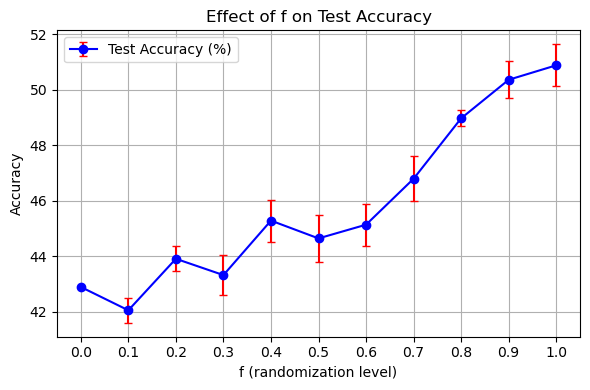

In [26]:
import torch
import matplotlib.pyplot as plt
from scipy import io
from scipy.io import loadmat

data = loadmat("shd_whole_inv.mat")
X = data["X"]  # shape: (samples, neurons, 100)
Y = data["Y"].ravel()
num_classes = len(np.unique(Y))

f_values = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
repeats = 5
all_means = []
all_stds = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def preprocess_test_dataset_dataloader(X, Y, f, batch_size=128, seed=42):
    np.random.seed(seed)
    N = len(Y)

    test_start, test_end = testing_range
    test_indices  = np.arange(int(N * test_start), int(N * test_end))
    print(f"Applying partial_randomize_spike_train with f={f} to TEST set only...")

    # === Only process test set
    X_test_proc  = partial_randomize_spike_train(X[test_indices], f=f)
    Y_test = Y[test_indices]

    test_ds  = SpikeTensorDataset(X_test_proc, Y_test)

    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return test_loader

def test_accuracy_repeats_dataloader(net, repeats, f, X, Y):
    acc_list = []
    for _ in range(repeats):
        test_loader = preprocess_test_dataset_dataloader(X, Y, f=f, batch_size=256, seed=np.random.randint(0, 10000))
        acc = test_accuracy(net, test_loader)
        acc_list.append(acc)
    return acc_list


for f in f_values:
    model_path = f"D:/forStudy/IRP/SG_SNN/sec2/sg/sg_whole_f{int(f*10):02d}.pt"
    print(f"\n=== Loading model {model_path} and testing (f={f}) ===")

    net = TutorialSNN(700, 200, num_classes)
    net.load_state_dict(torch.load(model_path, map_location='cuda'))
    net.to('cuda')
    net.eval()

    acc_list = test_accuracy_repeats_dataloader(net, repeats=repeats, f=f, X=X, Y=Y)
    mean_acc = np.mean(acc_list)
    std_acc  = np.std(acc_list)

    all_means.append(mean_acc)
    all_stds.append(std_acc)

    print(f"f={f:.1f}, Mean Acc={mean_acc:.2%}, Std={std_acc:.2%} (over {repeats} runs)")

plt.figure(figsize=(6, 4))

means_pct = [m * 100 for m in all_means]
stds_pct  = [s * 100 for s in all_stds]

plt.errorbar(f_values, means_pct, yerr=stds_pct,
             fmt='-o', color='b', ecolor='r', capsize=3,
             label='Test Accuracy (%)')

plt.xlabel("f (randomization level)")
plt.ylabel("Accuracy")
plt.title("Effect of f on Test Accuracy")
plt.xticks(f_values)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Using device: cuda

=== Loading model D:/forStudy/IRP/SG_SNN/sec2/sg/sg_part_f00.pt and testing (f=0.0) ===
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
f=0.0, Mean Acc=23.08%, Std=0.00% (over 5 runs)

=== Loading model D:/forStudy/IRP/SG_SNN/sec2/sg/sg_part_f01.pt and testing (f=0.1) ===
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
f=0.1, Mean Acc=24.96%, Std=0.87% (over 5 runs)

=== Lo

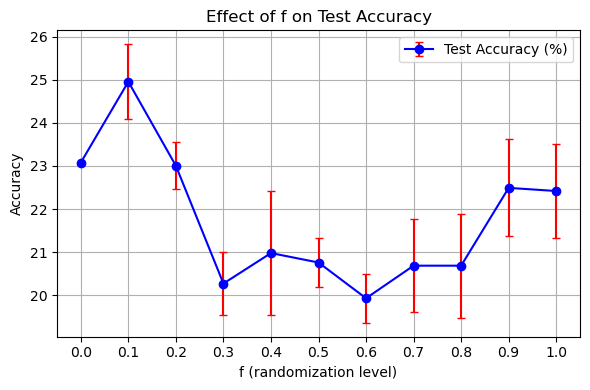

In [27]:
import torch
import matplotlib.pyplot as plt
from scipy import io
from scipy.io import loadmat

data = loadmat("shd_part_inv.mat")
X = data["X"]  # shape: (samples, neurons, 100)
Y = data["Y"].ravel()
num_classes = len(np.unique(Y))

f_values = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
repeats = 5
all_means = []
all_stds = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def preprocess_test_dataset_dataloader(X, Y, f, batch_size=128, seed=42):
    np.random.seed(seed)
    N = len(Y)

    test_start, test_end = testing_range
    test_indices  = np.arange(int(N * test_start), int(N * test_end))
    print(f"Applying partial_randomize_spike_train with f={f} to TEST set only...")

    # === Only process test set
    X_test_proc  = partial_randomize_spike_train(X[test_indices], f=f)
    Y_test = Y[test_indices]

    test_ds  = SpikeTensorDataset(X_test_proc, Y_test)

    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return test_loader

def test_accuracy_repeats_dataloader(net, repeats, f, X, Y):
    acc_list = []
    for _ in range(repeats):
        test_loader = preprocess_test_dataset_dataloader(X, Y, f=f, batch_size=256, seed=np.random.randint(0, 10000))
        acc = test_accuracy(net, test_loader)
        acc_list.append(acc)
    return acc_list


for f in f_values:
    model_path = f"D:/forStudy/IRP/SG_SNN/sec2/sg/sg_part_f{int(f*10):02d}.pt"
    print(f"\n=== Loading model {model_path} and testing (f={f}) ===")

    net = TutorialSNN(224, 200, num_classes)
    net.load_state_dict(torch.load(model_path, map_location='cuda'))
    net.to('cuda')
    net.eval()

    acc_list = test_accuracy_repeats_dataloader(net, repeats=repeats, f=f, X=X, Y=Y)
    mean_acc = np.mean(acc_list)
    std_acc  = np.std(acc_list)

    all_means.append(mean_acc)
    all_stds.append(std_acc)

    print(f"f={f:.1f}, Mean Acc={mean_acc:.2%}, Std={std_acc:.2%} (over {repeats} runs)")

plt.figure(figsize=(6, 4))

means_pct = [m * 100 for m in all_means]
stds_pct  = [s * 100 for s in all_stds]

plt.errorbar(f_values, means_pct, yerr=stds_pct,
             fmt='-o', color='b', ecolor='r', capsize=3,
             label='Test Accuracy (%)')

plt.xlabel("f (randomization level)")
plt.ylabel("Accuracy")
plt.title("Effect of f on Test Accuracy")
plt.xticks(f_values)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Maybe it means that when the spike timing information low to one specific level, the reversed spike timing informaiton will not be treated as the important feature to mislead the model

## Do another test for SHD-Part-Random224

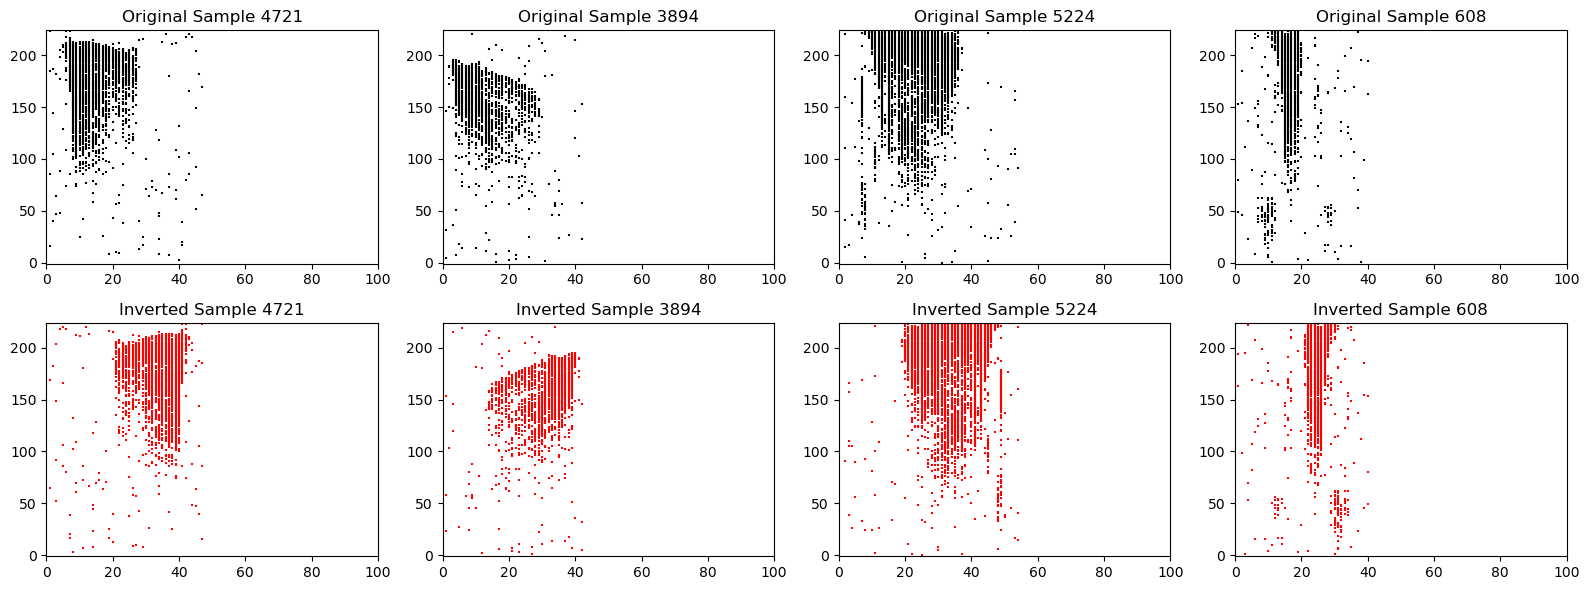

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
import random

data = loadmat("D:/forStudy/IRP/SG_SNN/sec2/sg/shd_part_random224.mat")
X = data["X"]  # (N, num_neurons, T)
Y = data["Y"].ravel()
N, num_neurons, T = X.shape

# For each sample, find the start and end time of spikes and flip the segments
X_inv = np.copy(X)
for i in range(N):
    spike_times = np.where(X[i] == 1)[1]
    if len(spike_times) == 0:
        continue
    t_start = np.min(spike_times)
    t_end = np.max(spike_times)
    for j in range(num_neurons):
        segment = X[i, j, t_start:t_end + 1]
        X_inv[i, j, t_start:t_end + 1] = np.flip(segment)

# Visualize original and inverted samples
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
sample_indices = random.sample(range(N), 4)
for i, idx in enumerate(sample_indices):
    ax1 = axes[0, i]
    for neuron in range(num_neurons):
        t_spike = np.where(X[idx, neuron] == 1)[0]
        ax1.scatter(t_spike, np.ones_like(t_spike) * neuron, s=3, marker='|', color='black')
    ax1.set_title(f"Original Sample {idx}")
    ax1.set_ylim([-1, num_neurons])
    ax1.set_xlim([0, T])
    
    ax2 = axes[1, i]
    for neuron in range(num_neurons):
        t_spike = np.where(X_inv[idx, neuron] == 1)[0]
        ax2.scatter(t_spike, np.ones_like(t_spike) * neuron, s=3, marker='|', color='red')
    ax2.set_title(f"Inverted Sample {idx}")
    ax2.set_ylim([-1, num_neurons])
    ax2.set_xlim([0, T])

plt.tight_layout()
plt.show()

savemat("shd_part_random224_inv.mat", {"X": X_inv, "Y": Y})


Using device: cuda

=== Loading model D:/forStudy/IRP/SG_SNN/sec2/sg/sg_part_random224_f00.pt and testing (f=0.0) ===
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
f=0.0, Mean Acc=45.79%, Std=0.00% (over 5 runs)

=== Loading model D:/forStudy/IRP/SG_SNN/sec2/sg/sg_part_random224_f01.pt and testing (f=0.1) ===
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
f=0.1, Mean Acc=45.13%, Std=0.89% (

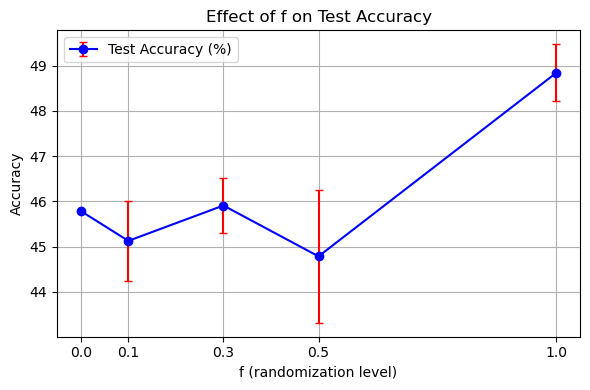

In [7]:
import torch
import matplotlib.pyplot as plt
from scipy import io
from scipy.io import loadmat

data = loadmat("shd_part_random224_inv.mat")
X = data["X"]  # shape: (samples, neurons, 100)
Y = data["Y"].ravel()
num_classes = len(np.unique(Y))

f_values = [0.0,0.1,0.3,0.5,1.0]
repeats = 5
all_means = []
all_stds = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def preprocess_test_dataset_dataloader(X, Y, f, batch_size=128, seed=42):
    np.random.seed(seed)
    N = len(Y)

    test_start, test_end = testing_range
    test_indices  = np.arange(int(N * test_start), int(N * test_end))
    print(f"Applying partial_randomize_spike_train with f={f} to TEST set only...")

    # === Only process test set
    X_test_proc  = partial_randomize_spike_train(X[test_indices], f=f)
    Y_test = Y[test_indices]

    test_ds  = SpikeTensorDataset(X_test_proc, Y_test)

    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return test_loader

def test_accuracy_repeats_dataloader(net, repeats, f, X, Y):
    acc_list = []
    for _ in range(repeats):
        test_loader = preprocess_test_dataset_dataloader(X, Y, f=f, batch_size=256, seed=np.random.randint(0, 10000))
        acc = test_accuracy(net, test_loader)
        acc_list.append(acc)
    return acc_list


for f in f_values:
    model_path = f"D:/forStudy/IRP/SG_SNN/sec2/sg/sg_part_random224_f{int(f*10):02d}.pt"
    print(f"\n=== Loading model {model_path} and testing (f={f}) ===")

    net = TutorialSNN(224, 200, num_classes)
    net.load_state_dict(torch.load(model_path, map_location='cuda'))
    net.to('cuda')
    net.eval()

    acc_list = test_accuracy_repeats_dataloader(net, repeats=repeats, f=f, X=X, Y=Y)
    mean_acc = np.mean(acc_list)
    std_acc  = np.std(acc_list)

    all_means.append(mean_acc)
    all_stds.append(std_acc)

    print(f"f={f:.1f}, Mean Acc={mean_acc:.2%}, Std={std_acc:.2%} (over {repeats} runs)")

plt.figure(figsize=(6, 4))

means_pct = [m * 100 for m in all_means]
stds_pct  = [s * 100 for s in all_stds]

plt.errorbar(f_values, means_pct, yerr=stds_pct,
             fmt='-o', color='b', ecolor='r', capsize=3,
             label='Test Accuracy (%)')

plt.xlabel("f (randomization level)")
plt.ylabel("Accuracy")
plt.title("Effect of f on Test Accuracy")
plt.xticks(f_values)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Test the norm one

Using device: cuda

=== Loading model D:/forStudy/IRP/SG_SNN/sec2/sg/sg_norm_f00.pt and testing (f=0.0) ===
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
Applying partial_randomize_spike_train with f=0.0 to TEST set only...
f=0.0, Mean Acc=4.27%, Std=0.00% (over 5 runs)

=== Loading model D:/forStudy/IRP/SG_SNN/sec2/sg/sg_norm_f01.pt and testing (f=0.1) ===
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
Applying partial_randomize_spike_train with f=0.1 to TEST set only...
f=0.1, Mean Acc=7.59%, Std=0.53% (over 5 runs)

=== Load

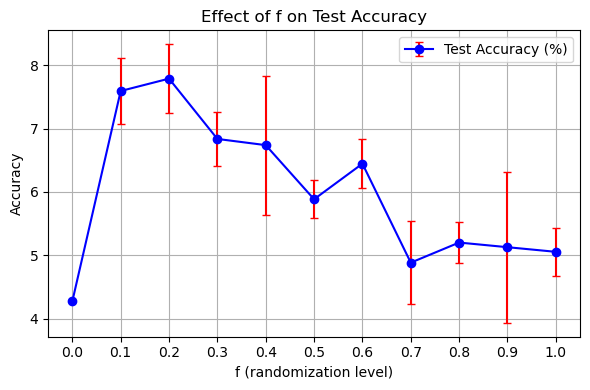

In [28]:
import torch
import matplotlib.pyplot as plt
from scipy import io
from scipy.io import loadmat

data = loadmat("shd_norm_inv.mat")
X = data["X"]  # shape: (samples, neurons, 100)
Y = data["Y"].ravel()
num_classes = len(np.unique(Y))

f_values = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
repeats = 5
all_means = []
all_stds = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def preprocess_test_dataset_dataloader(X, Y, f, batch_size=128, seed=42):
    np.random.seed(seed)
    N = len(Y)

    test_start, test_end = testing_range
    test_indices  = np.arange(int(N * test_start), int(N * test_end))
    print(f"Applying partial_randomize_spike_train with f={f} to TEST set only...")

    # === Only process test set
    X_test_proc  = partial_randomize_spike_train(X[test_indices], f=f)
    Y_test = Y[test_indices]

    test_ds  = SpikeTensorDataset(X_test_proc, Y_test)

    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return test_loader

def test_accuracy_repeats_dataloader(net, repeats, f, X, Y):
    acc_list = []
    for _ in range(repeats):
        test_loader = preprocess_test_dataset_dataloader(X, Y, f=f, batch_size=256, seed=np.random.randint(0, 10000))
        acc = test_accuracy(net, test_loader)
        acc_list.append(acc)
    return acc_list


for f in f_values:
    model_path = f"D:/forStudy/IRP/SG_SNN/sec2/sg/sg_norm_f{int(f*10):02d}.pt"
    print(f"\n=== Loading model {model_path} and testing (f={f}) ===")

    net = TutorialSNN(224, 200, num_classes)
    net.load_state_dict(torch.load(model_path, map_location='cuda'))
    net.to('cuda')
    net.eval()

    acc_list = test_accuracy_repeats_dataloader(net, repeats=repeats, f=f, X=X, Y=Y)
    mean_acc = np.mean(acc_list)
    std_acc  = np.std(acc_list)

    all_means.append(mean_acc)
    all_stds.append(std_acc)

    print(f"f={f:.1f}, Mean Acc={mean_acc:.2%}, Std={std_acc:.2%} (over {repeats} runs)")

plt.figure(figsize=(6, 4))

means_pct = [m * 100 for m in all_means]
stds_pct  = [s * 100 for s in all_stds]

plt.errorbar(f_values, means_pct, yerr=stds_pct,
             fmt='-o', color='b', ecolor='r', capsize=3,
             label='Test Accuracy (%)')

plt.xlabel("f (randomization level)")
plt.ylabel("Accuracy")
plt.title("Effect of f on Test Accuracy")
plt.xticks(f_values)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
